<a href="https://colab.research.google.com/github/dansarmiento/machine_learning_notebooks/blob/main/DNN_Game_outcome_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Required imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Step 1: Load the dataset
url = "https://docs.google.com/spreadsheets/d/1PSx39rGR4hu1r-Ral3sqYMcQpuXU2Xk8MIGSoRYg1Wc/gviz/tq?tqx=out:csv"
data = pd.read_csv(url)

# Step 2: Split into features and target
X = data.drop('win', axis=1)
y = data['win']

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Print shapes to confirm
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

X_train_tensor shape: torch.Size([800, 8])
y_train_tensor shape: torch.Size([800])


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Step 1: Set input dimension from the training features
input_dim = X_train_tensor.shape[1]

# Step 2: Initialize the model
model = LogisticRegressionModel(input_dim)

# Step 3: Define the loss function (Binary Cross-Entropy Loss)
criterion = nn.BCELoss()

# Step 4: Initialize the optimizer (SGD with learning rate of 0.01)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Confirm everything is set up
print(model)

LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [4]:
# Set number of epochs
epochs = 1000

# Training loop
for epoch in range(epochs):
    model.train()  # Set model to training mode
    optimizer.zero_grad()  # Zero out gradients

    # Forward pass
    outputs = model(X_train_tensor).squeeze()  # Squeeze to match shape of y_train

    # Compute loss
    loss = criterion(outputs, y_train_tensor)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

# Model evaluation
model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    train_preds = model(X_train_tensor).squeeze()
    test_preds = model(X_test_tensor).squeeze()

# Apply threshold of 0.5 to get predicted labels
train_preds_class = (train_preds >= 0.5).float()
test_preds_class = (test_preds >= 0.5).float()

# Calculate accuracy
train_accuracy = (train_preds_class == y_train_tensor).float().mean().item()
test_accuracy = (test_preds_class == y_test_tensor).float().mean().item()

# Print accuracies
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")


Epoch [100/1000], Loss: 0.7085
Epoch [200/1000], Loss: 0.6995
Epoch [300/1000], Loss: 0.6939
Epoch [400/1000], Loss: 0.6905
Epoch [500/1000], Loss: 0.6884
Epoch [600/1000], Loss: 0.6872
Epoch [700/1000], Loss: 0.6864
Epoch [800/1000], Loss: 0.6859
Epoch [900/1000], Loss: 0.6857
Epoch [1000/1000], Loss: 0.6855
Training Accuracy: 54.00%
Testing Accuracy: 48.00%


In [5]:
# Reinitialize the model and optimizer with L2 regularization
model_l2 = LogisticRegressionModel(input_dim)
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=0.01, weight_decay=0.01)  # L2 regularization

# Loss function stays the same
criterion = nn.BCELoss()

# Training loop with L2 regularization
epochs = 1000
for epoch in range(epochs):
    model_l2.train()
    optimizer_l2.zero_grad()

    outputs = model_l2(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer_l2.step()

    if (epoch + 1) % 100 == 0:
        print(f"[L2 Reg] Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

# Evaluate optimized model
model_l2.eval()
with torch.no_grad():
    train_preds = model_l2(X_train_tensor).squeeze()
    test_preds = model_l2(X_test_tensor).squeeze()

# Apply threshold for classification
train_preds_class = (train_preds >= 0.5).float()
test_preds_class = (test_preds >= 0.5).float()

# Compute accuracy
train_accuracy = (train_preds_class == y_train_tensor).float().mean().item()
test_accuracy = (test_preds_class == y_test_tensor).float().mean().item()

# Print accuracies
print(f"[L2 Reg] Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"[L2 Reg] Testing Accuracy: {test_accuracy * 100:.2f}%")

[L2 Reg] Epoch [100/1000], Loss: 0.6914
[L2 Reg] Epoch [200/1000], Loss: 0.6889
[L2 Reg] Epoch [300/1000], Loss: 0.6874
[L2 Reg] Epoch [400/1000], Loss: 0.6865
[L2 Reg] Epoch [500/1000], Loss: 0.6860
[L2 Reg] Epoch [600/1000], Loss: 0.6857
[L2 Reg] Epoch [700/1000], Loss: 0.6855
[L2 Reg] Epoch [800/1000], Loss: 0.6854
[L2 Reg] Epoch [900/1000], Loss: 0.6854
[L2 Reg] Epoch [1000/1000], Loss: 0.6853
[L2 Reg] Training Accuracy: 54.75%
[L2 Reg] Testing Accuracy: 50.00%


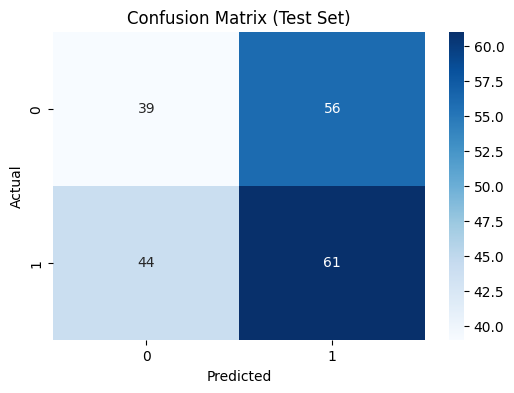

Classification Report:

              precision    recall  f1-score   support

         0.0     0.4699    0.4105    0.4382        95
         1.0     0.5214    0.5810    0.5495       105

    accuracy                         0.5000       200
   macro avg     0.4956    0.4957    0.4939       200
weighted avg     0.4969    0.5000    0.4967       200



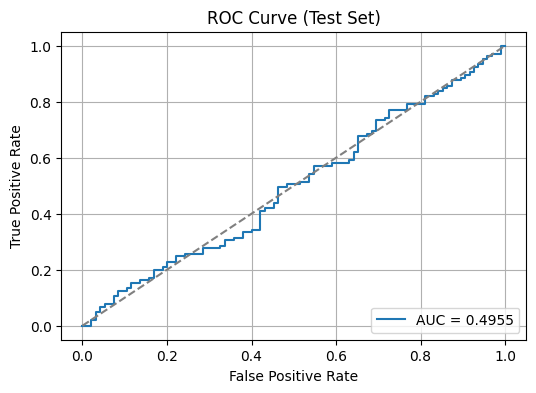

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate on test set
model_l2.eval()
with torch.no_grad():
    test_probs = model_l2(X_test_tensor).squeeze().numpy()
    test_preds = (test_probs >= 0.5).astype(int)
    y_true = y_test_tensor.numpy()

# 1. Confusion Matrix
cm = confusion_matrix(y_true, test_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. Classification Report
print("Classification Report:\n")
print(classification_report(y_true, test_preds, digits=4))

# 3. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_true, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [7]:
# Save the model
torch.save(model_l2.state_dict(), 'logistic_model_l2.pth')

# Load the model
loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load('logistic_model_l2.pth'))

# Ensure the loaded model is in evaluation mode
loaded_model.eval()

# Evaluate the loaded model
with torch.no_grad():
    test_probs_loaded = loaded_model(X_test_tensor).squeeze().numpy()
    test_preds_loaded = (test_probs_loaded >= 0.5).astype(int)

# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_loaded = accuracy_score(y_test_tensor.numpy(), test_preds_loaded)

print(f"Accuracy of loaded model on test set: {accuracy_loaded * 100:.2f}%")


Accuracy of loaded model on test set: 50.00%


In [8]:
# Define learning rates to test
learning_rates = [0.01, 0.05, 0.1]
epochs = 100
best_accuracy = 0
best_lr = None

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    # Reinitialize model and optimizer
    model = LogisticRegressionModel(input_dim)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    # Train the model
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor).squeeze()
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_probs = model(X_test_tensor).squeeze().numpy()
        test_preds = (test_probs >= 0.5).astype(int)
        accuracy = accuracy_score(y_test_tensor.numpy(), test_preds)

    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    # Check if best
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_lr = lr

# Final result
print(f"\nBest Learning Rate: {best_lr}")
print(f"Highest Test Accuracy: {best_accuracy * 100:.2f}%")



Training with learning rate: 0.01
Test Accuracy: 52.00%

Training with learning rate: 0.05
Test Accuracy: 49.00%

Training with learning rate: 0.1
Test Accuracy: 50.50%

Best Learning Rate: 0.01
Highest Test Accuracy: 52.00%


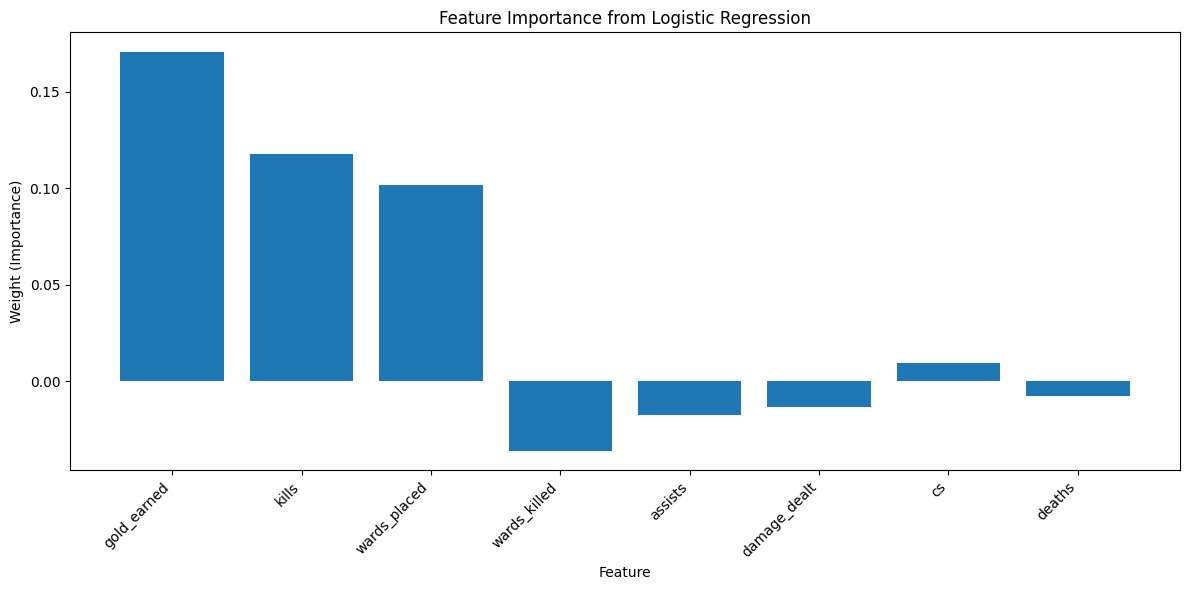

In [9]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Extract the weights of the linear layer (model_l2 assumed to be the trained model)
weights = model_l2.linear.weight.data.numpy().flatten()

# Create a DataFrame for feature importance
features = X.columns  # Ensure X is the original DataFrame used for training (before tensor conversion)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': weights
})

# Sort by absolute importance
feature_importance['AbsImportance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='AbsImportance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Feature')
plt.ylabel('Weight (Importance)')
plt.title('Feature Importance from Logistic Regression')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
